In [1]:
# ----------------------------------------
# 📦 1. Import Required Libraries
# ----------------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
 
from scipy.stats import skew
# ----------------------------------------
# 📥 2. Load Datasets
# ----------------------------------------
train_df = pd.read_csv("house_prices/train.csv")
test_df = pd.read_csv("house_prices/test.csv")
original_test_df = test_df.copy()

# ----------------------------------------
# 🔎 3. Visualize Raw Data
# ----------------------------------------
# descriptive statistics
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [2]:
# ----------------------------------------
# 🧼 4. Clean & Encode Data (Train)
# ----------------------------------------
train_df = train_df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence'])

In [3]:
train_df['MasVnrType'] = train_df['MasVnrType'].fillna("None")

In [4]:
fireplace_quality_map = {
    "Ex": 5,
    "Gd": 4,
    "TA": 3,
    "Fa": 2,
    "Po": 1,
    np.nan: 0
}
train_df['FireplaceQu'] = train_df['FireplaceQu'].map(fireplace_quality_map)

In [5]:
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(train_df["LotFrontage"].median())

In [6]:
none_fill_cols = [
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1'
]
zero_fill_cols = [
    'MasVnrArea', 'GarageYrBlt'
]

for col in none_fill_cols:
    train_df[col] = train_df[col].fillna("None")

for col in zero_fill_cols:
    train_df[col] = train_df[col].fillna(0) 

In [7]:
train_df['Electrical'] = train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])

In [8]:
train_df = pd.get_dummies(train_df, drop_first=True)

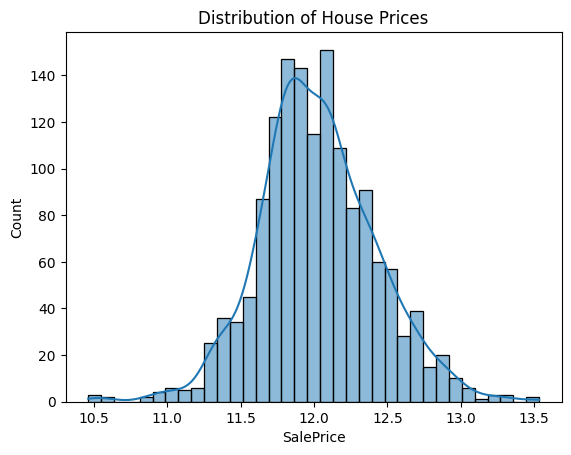

Skewness: 0.12
Top 10 Correlated Features with SalePrice:
SalePrice       1.000000
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
ExterQual_TA    0.595882
FullBath        0.594771
YearBuilt       0.586570
Name: SalePrice, dtype: float64


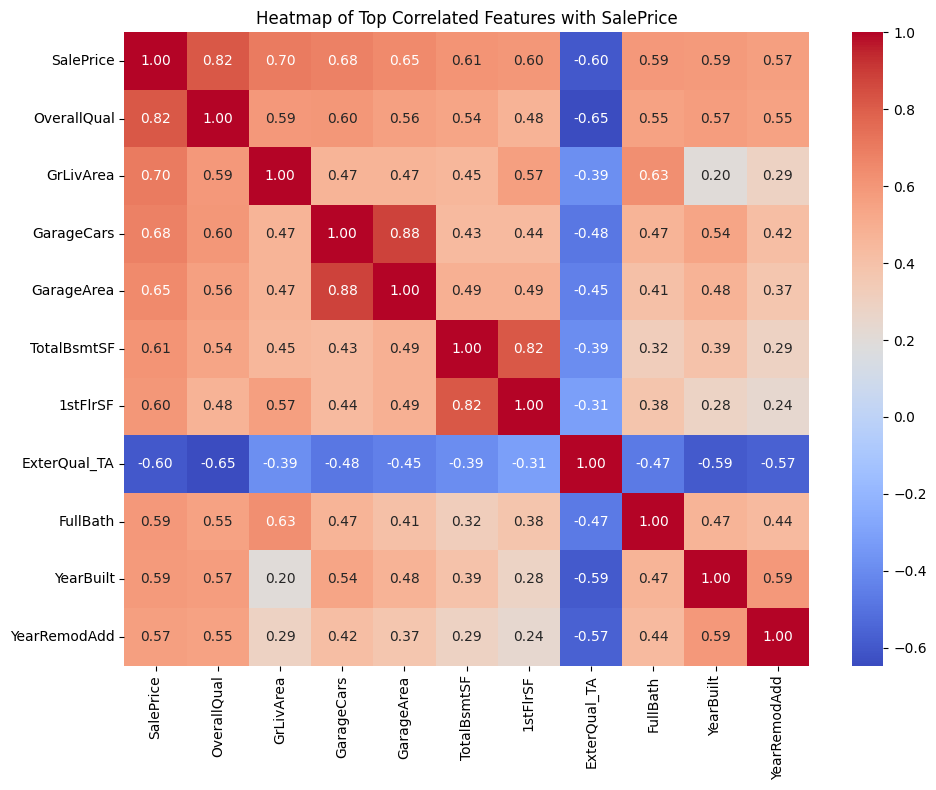

In [9]:
# ----------------------------------------
# 🧼 5. Clean & Encode Data (Test)
# ----------------------------------------
test_df = test_df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence'])
test_df['MasVnrType'] = test_df['MasVnrType'].fillna("None")
test_df['FireplaceQu'] = test_df['FireplaceQu'].map(fireplace_quality_map)
test_df['LotFrontage'] = test_df['LotFrontage'].fillna(test_df["LotFrontage"].median())
for col in none_fill_cols:
    test_df[col] = test_df[col].fillna("None")

for col in zero_fill_cols:
    test_df[col] = test_df[col].fillna(0) 
test_df['Electrical'] = test_df['Electrical'].fillna(test_df['Electrical'].mode()[0])
test_df = pd.get_dummies(test_df, drop_first=True)

# ----------------------------------------
# 📊 6. Exploratory Data Analysis (EDA)
# ----------------------------------------
# Log Transformation
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])  # log(1 + SalePrice)

sns.histplot(train_df['SalePrice'], kde=True)
plt.title("Distribution of House Prices")
plt.show()

# Measure skewness
saleprice_skew = skew(train_df['SalePrice'])
print(f"Skewness: {saleprice_skew:.2f}")


# 1. Compute numeric correlation matrix
corr_matrix = train_df.corr(numeric_only=True)

# 2. Identify features most correlated with SalePrice
saleprice_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False)

# 3. Display top 10 features (including SalePrice itself)
print("Top 10 Correlated Features with SalePrice:")
print(saleprice_corr.head(10))

# 4. Plot heatmap for top correlated features only
top_corr_features = saleprice_corr.head(11).index  # top 10 + SalePrice
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap of Top Correlated Features with SalePrice")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 🏗️ 7. Feature Engineering
# ----------------------------------------
train_df['Remodeled'] = (train_df['YearRemodAdd'] > train_df['YearBuilt']).astype(int)
train_df['HouseAge'] = 2025 - train_df['YearBuilt']
train_df['RemodAge'] = 2025 - train_df['YearRemodAdd']
train_df['GarageUtil'] = train_df['GarageArea'] / train_df['GarageCars'].replace(0, np.nan)
train_df['GarageUtil'] = train_df['GarageUtil'].fillna(0)
train_df['TotalUsableArea'] = train_df['GrLivArea'] + train_df['GarageArea']
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['1stFlrSF']
train_df = train_df.drop(columns=['GarageArea'])

test_df['Remodeled'] = (test_df['YearRemodAdd'] > test_df['YearBuilt']).astype(int)
test_df['HouseAge'] = 2025 - test_df['YearBuilt']
test_df['RemodAge'] = 2025 - test_df['YearRemodAdd']
test_df['GarageUtil'] = test_df['GarageArea'] / test_df['GarageCars'].replace(0, np.nan)
test_df['GarageUtil'] = test_df['GarageUtil'].fillna(0)
test_df['TotalUsableArea'] = test_df['GrLivArea'] + test_df['GarageArea']
test_df['TotalSF'] = test_df['TotalBsmtSF'] + test_df['1stFlrSF']
test_df = test_df.drop(columns=['GarageArea'])

In [10]:
# check for missing values
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Series([], dtype: int64)


In [11]:
%matplotlib inline

In [ ]:
# ----------------------------------------
# 🤖 8. Model Training and Validation
# ----------------------------------------
# Split Data
X = train_df.drop(columns=['SalePrice'])
y = train_df['SalePrice']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])


# Train Model
model = SVR()
param_grid = {
    'svr__kernel': ['rbf', 'linear'],
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5],
    'svr__gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    refit=True,  # ✅ Ensures best model is refit on full training set
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best RMSE:", -grid_search.best_score_)  # negative because of neg RMSE scoring
from sklearn.metrics import mean_squared_error

y_pred = grid_search.predict(X_val)
rmse = mean_squared_error(y_val, y_pred, squared=False)
print("Validation RMSE:", rmse)

# ----------------------------------------
# 📈 9. Model Evaluation
# ----------------------------------------
# Plot predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r')
plt.xlabel("Actual SalePrice (log)")
plt.ylabel("Predicted SalePrice (log)")
plt.title("SVR: Predicted vs Actual")
plt.tight_layout()
plt.show()

residuals = y_val - y_pred

plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color='purple')
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

rmse = mean_squared_error(y_val, y_pred, squared=False)
r2 = r2_score(y_val, y_pred)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R² Score: {r2:.4f}")

# Use the same pipeline and scoring
cv_rmse = cross_val_score(grid_search.best_estimator_, X, y,
                          scoring='neg_root_mean_squared_error', cv=5)

cv_rmse = -cv_rmse  # negate because sklearn returns negative for RMSE

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_rmse, color='teal')
plt.title("Cross-Validation RMSE per Fold")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks(range(1, 6))
plt.ylim(0, max(cv_rmse) + 0.02)
plt.tight_layout()
plt.show()

print(f"Mean CV RMSE: {cv_rmse.mean():.4f}")
print(f"Std Dev: {cv_rmse.std():.4f}")
# ----------------------------------------
# 📤 10. Create Submission File
# ----------------------------------------
test_predictions = grid_search.predict(test_df)

submission = pd.DataFrame({
    'Id': original_test_df['Id'],
    'SalePrice': np.expm1(test_predictions)  # undo log1p
})

submission.to_csv("house_prices.csv", index=False)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [ ]:
# ----------------------------------------
#  11. Other
# ----------------------------------------
# Feature Importance
importances = model.feature_importances_
features = X.columns
pd.Series(importances, index=features).sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()